Outline

This notebook is used to conduct data analysis step by step before entering preprocessing and prediction. This will create a preprocess function to use.

Notebook Outline

1. Load Data And Library
2. Check Data Basic Information
3. Data Visualization
4. Correlation Map
5. Conclusion
6. Preprocess function

# Big upadte: Claude Code

I use claude code to analyze data with me and create a report.

link: [claude code EDA](https://github.com/wesleyhuan/Kaggle_S6E5_EDA)


Key summary:

* The dataset has 439,140 rows x 16 columns, using 127.3 MB of memory
* No missing values at all (typical of an already-cleaned Kaggle dataset)
* The target PitNextLap is binary with a class imbalance of roughly 80 : 20 (negative : positive)
* Driver is a high-cardinality categorical (887 values) mixing 3-letter real abbreviations with D000-style anonymized codes
* LapTime has an extreme tail (max 2507s) caused by safety-car or red-flag
* laps TyreLife, LapNumber, Stint and RaceProgress are positively correlated with the target (r ~ 0.19~0.27)
* Cumulative_Degradation is negatively correlated with the target (r ~ -0.17)
* Pit rate differs hugely by Compound: HARD 32.8%, MEDIUM 10.1%, WET 2.5%
* Race includes Pre-Season Testing, whose pitting logic differs from real races
* Pit probability peaks mid-race (RaceProgress 0.4~0.6), forming an inverted-U shape

# Load Data And Library

In [1]:
# import necessary library
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [2]:
# config
class CFG:
    train_csv = '/kaggle/input/competitions/playground-series-s6e5/train.csv'
    test_csv = '/kaggle/input/competitions/playground-series-s6e5/test.csv'
    sample_submission_csv = '/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv'
    N_FOLDS = 5
    RANDOM_SEED = 42
    
#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
train = pd.read_csv(CFG.train_csv)
test = pd.read_csv(CFG.test_csv)

# Check Data Basic Information

In [4]:
#check what is in the data
print("------------train data------------")
display(train.head())
print(train.describe())
print("------------test data------------")
display(test.head())
print(test.describe())

------------train data------------


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


                  id           Year        PitStop      LapNumber  \
count  439140.000000  439140.000000  439140.000000  439140.000000   
mean   219569.500000    2023.523544       0.136118      23.105909   
std    126768.942943       1.024930       0.342915      16.958261   
min         0.000000    2022.000000       0.000000       1.000000   
25%    109784.750000    2023.000000       0.000000       9.000000   
50%    219569.500000    2024.000000       0.000000      19.000000   
75%    329354.250000    2024.000000       0.000000      36.000000   
max    439139.000000    2025.000000       1.000000      78.000000   

               Stint       TyreLife       Position    LapTime (s)  \
count  439140.000000  439140.000000  439140.000000  439140.000000   
mean        1.789113      14.158231       9.630339      90.948735   
std         0.950194       9.801338       5.278770      19.772769   
min         1.000000       1.000000       1.000000      67.694000   
25%         1.000000       6.0000

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


                  id           Year        PitStop      LapNumber  \
count  188165.000000  188165.000000  188165.000000  188165.000000   
mean   533222.000000    2023.528440       0.136263      23.050185   
std     54318.701038       1.025376       0.343069      17.002292   
min    439140.000000    2022.000000       0.000000       1.000000   
25%    486181.000000    2023.000000       0.000000       9.000000   
50%    533222.000000    2024.000000       0.000000      19.000000   
75%    580263.000000    2024.000000       0.000000      36.000000   
max    627304.000000    2025.000000       1.000000      77.000000   

               Stint       TyreLife       Position    LapTime (s)  \
count  188165.000000  188165.000000  188165.000000  188165.000000   
mean        1.784237      14.160625       9.604539      90.986869   
std         0.948800       9.852778       5.273444      20.855248   
min         1.000000       1.000000       1.000000      67.017000   
25%         1.000000       6.0000

In [5]:
# check if there is miss data in training data or testing data
print(train.isnull().sum())
print(test.isnull().sum())

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64
id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64


# Data Visualization

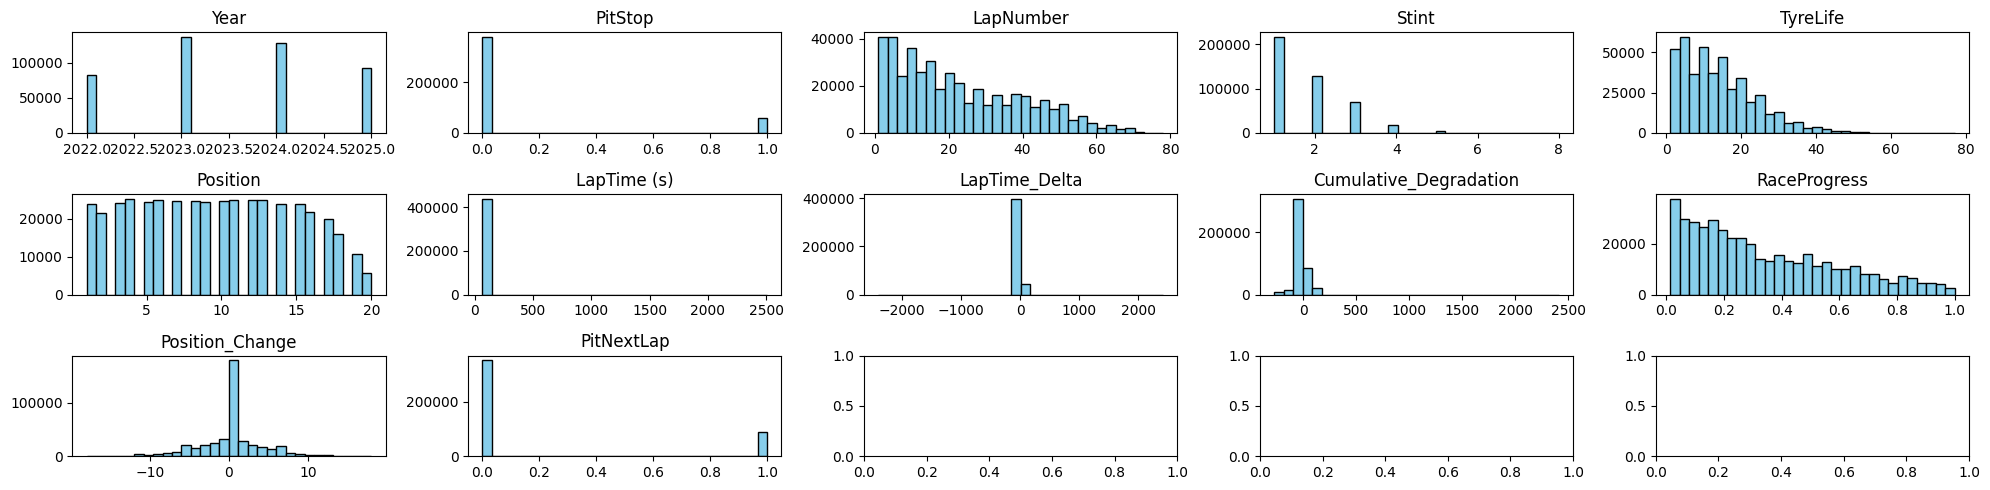

In [6]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id']]
total_col = len(numeric_cols)
subplot_x = int(total_col / 5) + 1
subplot_y = 5

fig, axs = plt.subplots(subplot_x, subplot_y, figsize=(20, 5)) # Adjust grid size as needed
axs = axs.flatten() # Flattens the 2D grid to 1D

for i, col in enumerate(numeric_cols):
    if i < len(axs):
        axs[i].hist(train[col], bins=30, color='skyblue', edgecolor='black')
        axs[i].set_title(col)
    else:
        axs[i].axis('off') # Hide unused subplots

plt.tight_layout()
plt.show()

In [7]:
non_numeric_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_numeric_cols:
    print(col," : ",train[col].unique())

Driver  :  ['D109' 'D086' 'ZON' 'SPE' 'D019' 'D012' 'D104' 'D082' 'BEL' 'YAM' 'MAS'
 'D010' 'D063' 'D196' 'D132' 'D047' 'PRO' 'D066' 'DRA' 'PEA' 'HAD' 'HUL'
 'COU' 'D036' 'D205' 'BER' 'VIL' 'GUT' 'TUR' 'D089' 'D055' 'D189' 'D071'
 'DAM' 'D144' 'D384' 'D263' 'D117' 'D120' 'D054' 'D184' 'D214' 'IDE'
 'D216' 'D101' 'D160' 'WIL' 'CAR' 'D251' 'D106' 'D083' 'WAR' 'D065' 'MIN'
 'D293' 'BIA' 'D125' 'D073' 'ALE' 'D007' 'D009' 'D202' 'NOR' 'FRE' 'D057'
 'D177' 'D049' 'ALG' 'SUT' 'D312' 'D159' 'D219' 'ROS' 'D166' 'D218' 'D045'
 'D197' 'GIO' 'DIR' 'D138' 'WEB' 'D070' 'D097' 'LEC' 'D050' 'D369' 'HYD'
 'D355' 'D032' 'D292' 'BEA' 'D001' 'D232' 'D211' 'DIN' 'D157' 'NAK' 'TAY'
 'STR' 'D325' 'D028' 'RIC' 'ZHO' 'GAS' 'D041' 'D014' 'D283' 'WUR' 'D061'
 'D281' 'D046' 'TSU' 'D170' 'D122' 'D210' 'D191' 'D074' 'SHA' 'D128'
 'D254' 'D285' 'CAN' 'FUJ' 'D152' 'D038' 'FER' 'FON' 'ROB' 'D002' 'D020'
 'D224' 'D244' 'MAR' 'D096' 'D116' 'D081' 'SEN' 'D064' 'COL' 'D194' 'D035'
 'SAT' 'SCH' 'D053' 'TAK' 'ARN' 'D023' 'D

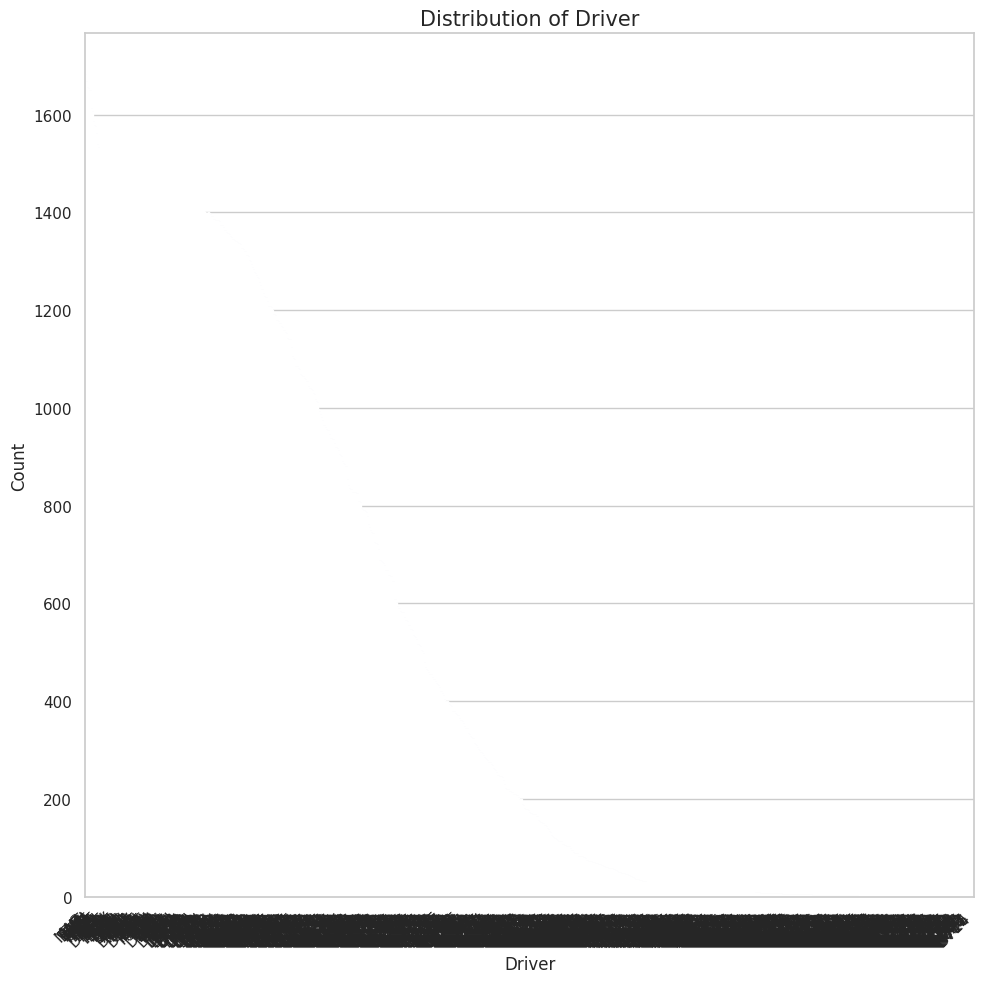

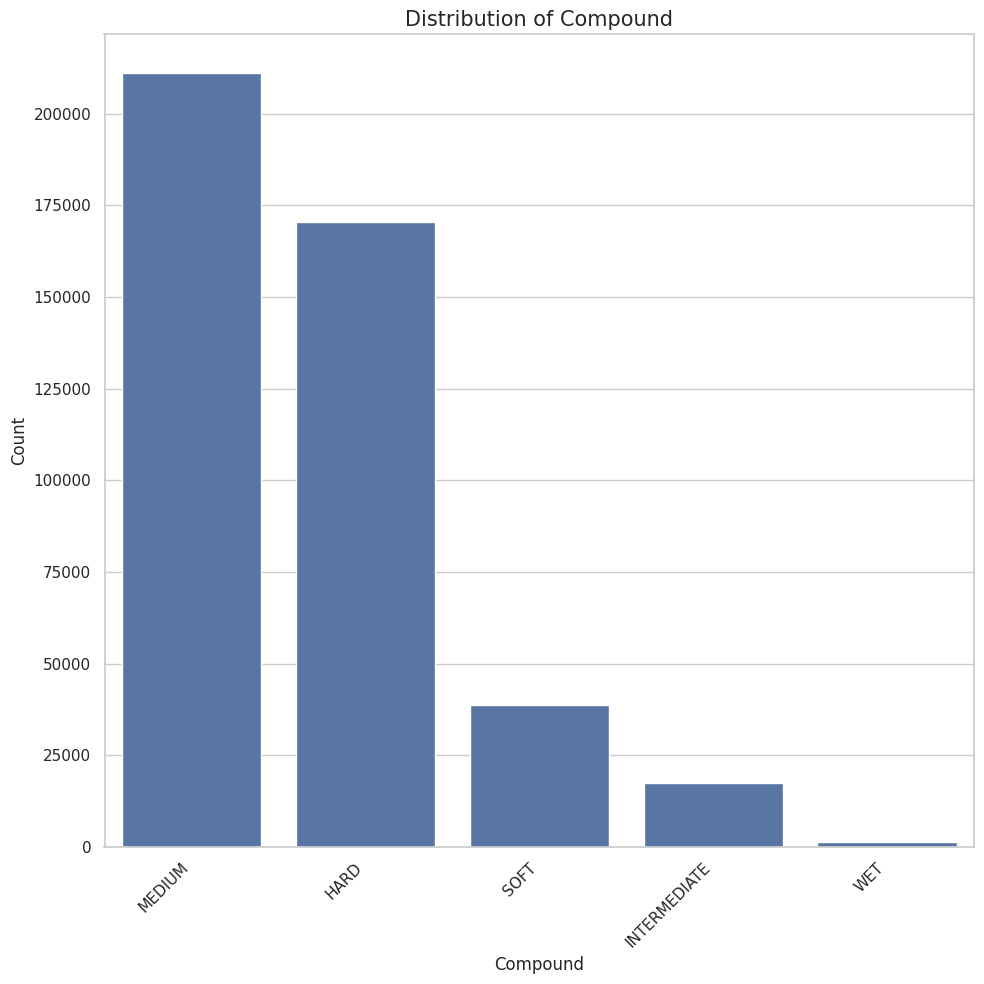

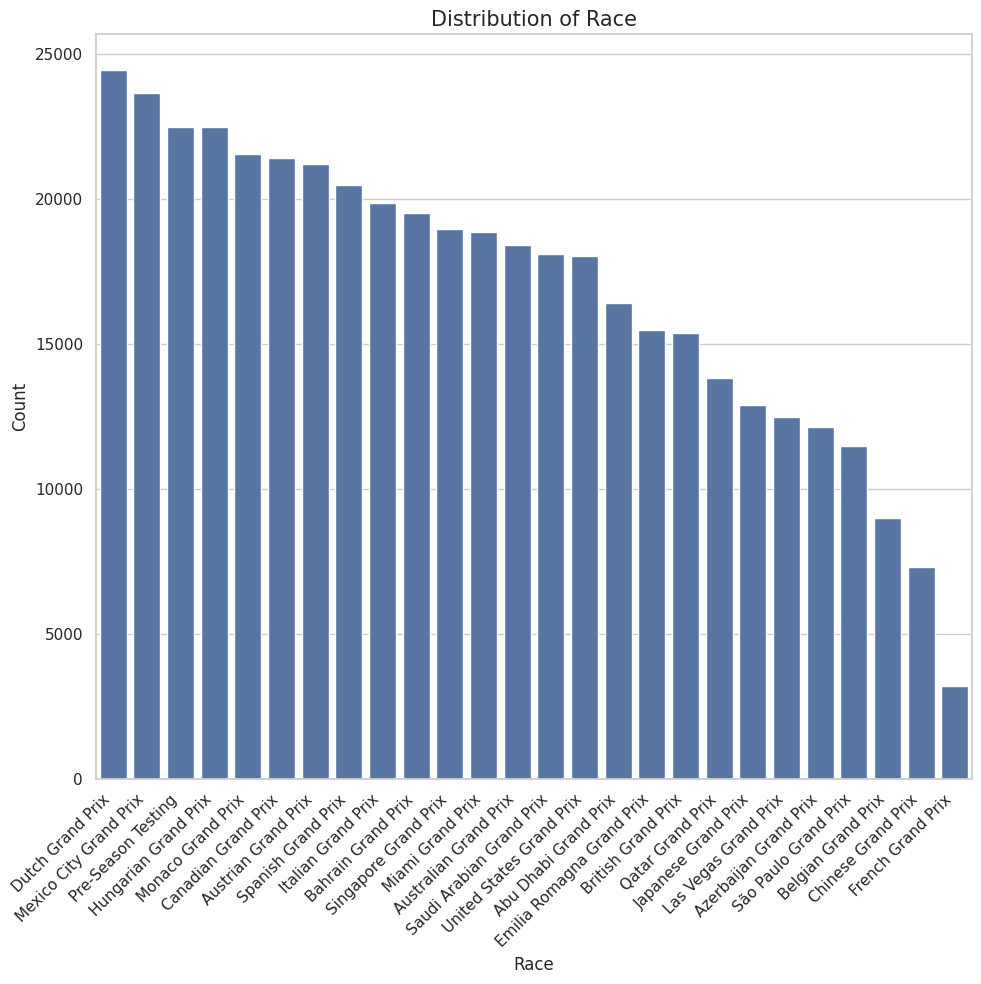

In [8]:
sns.set(style="whitegrid")
#PLOT NON NUMERIC DATA
for col in non_numeric_cols:
    # (width, height)
    plt.figure(figsize=(10, 10))
    
    # order plot with most number to least number data
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    
    # title and x label
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # rotate to avoid x axis on top of each other
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

Key note:

1. Driver feature have too many individual data this need to use different approach to preprocess(method could be the key to have good score)
2. Compound feature can use mapping to encode.
3. Race feature will use One-Hot Encoding

# Correlation Map

In [9]:
train_raw = train.drop(columns=['id','Driver'])
train_raw.head()

,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [10]:
one_hot_encoded_train_raw = pd.get_dummies(train_raw)

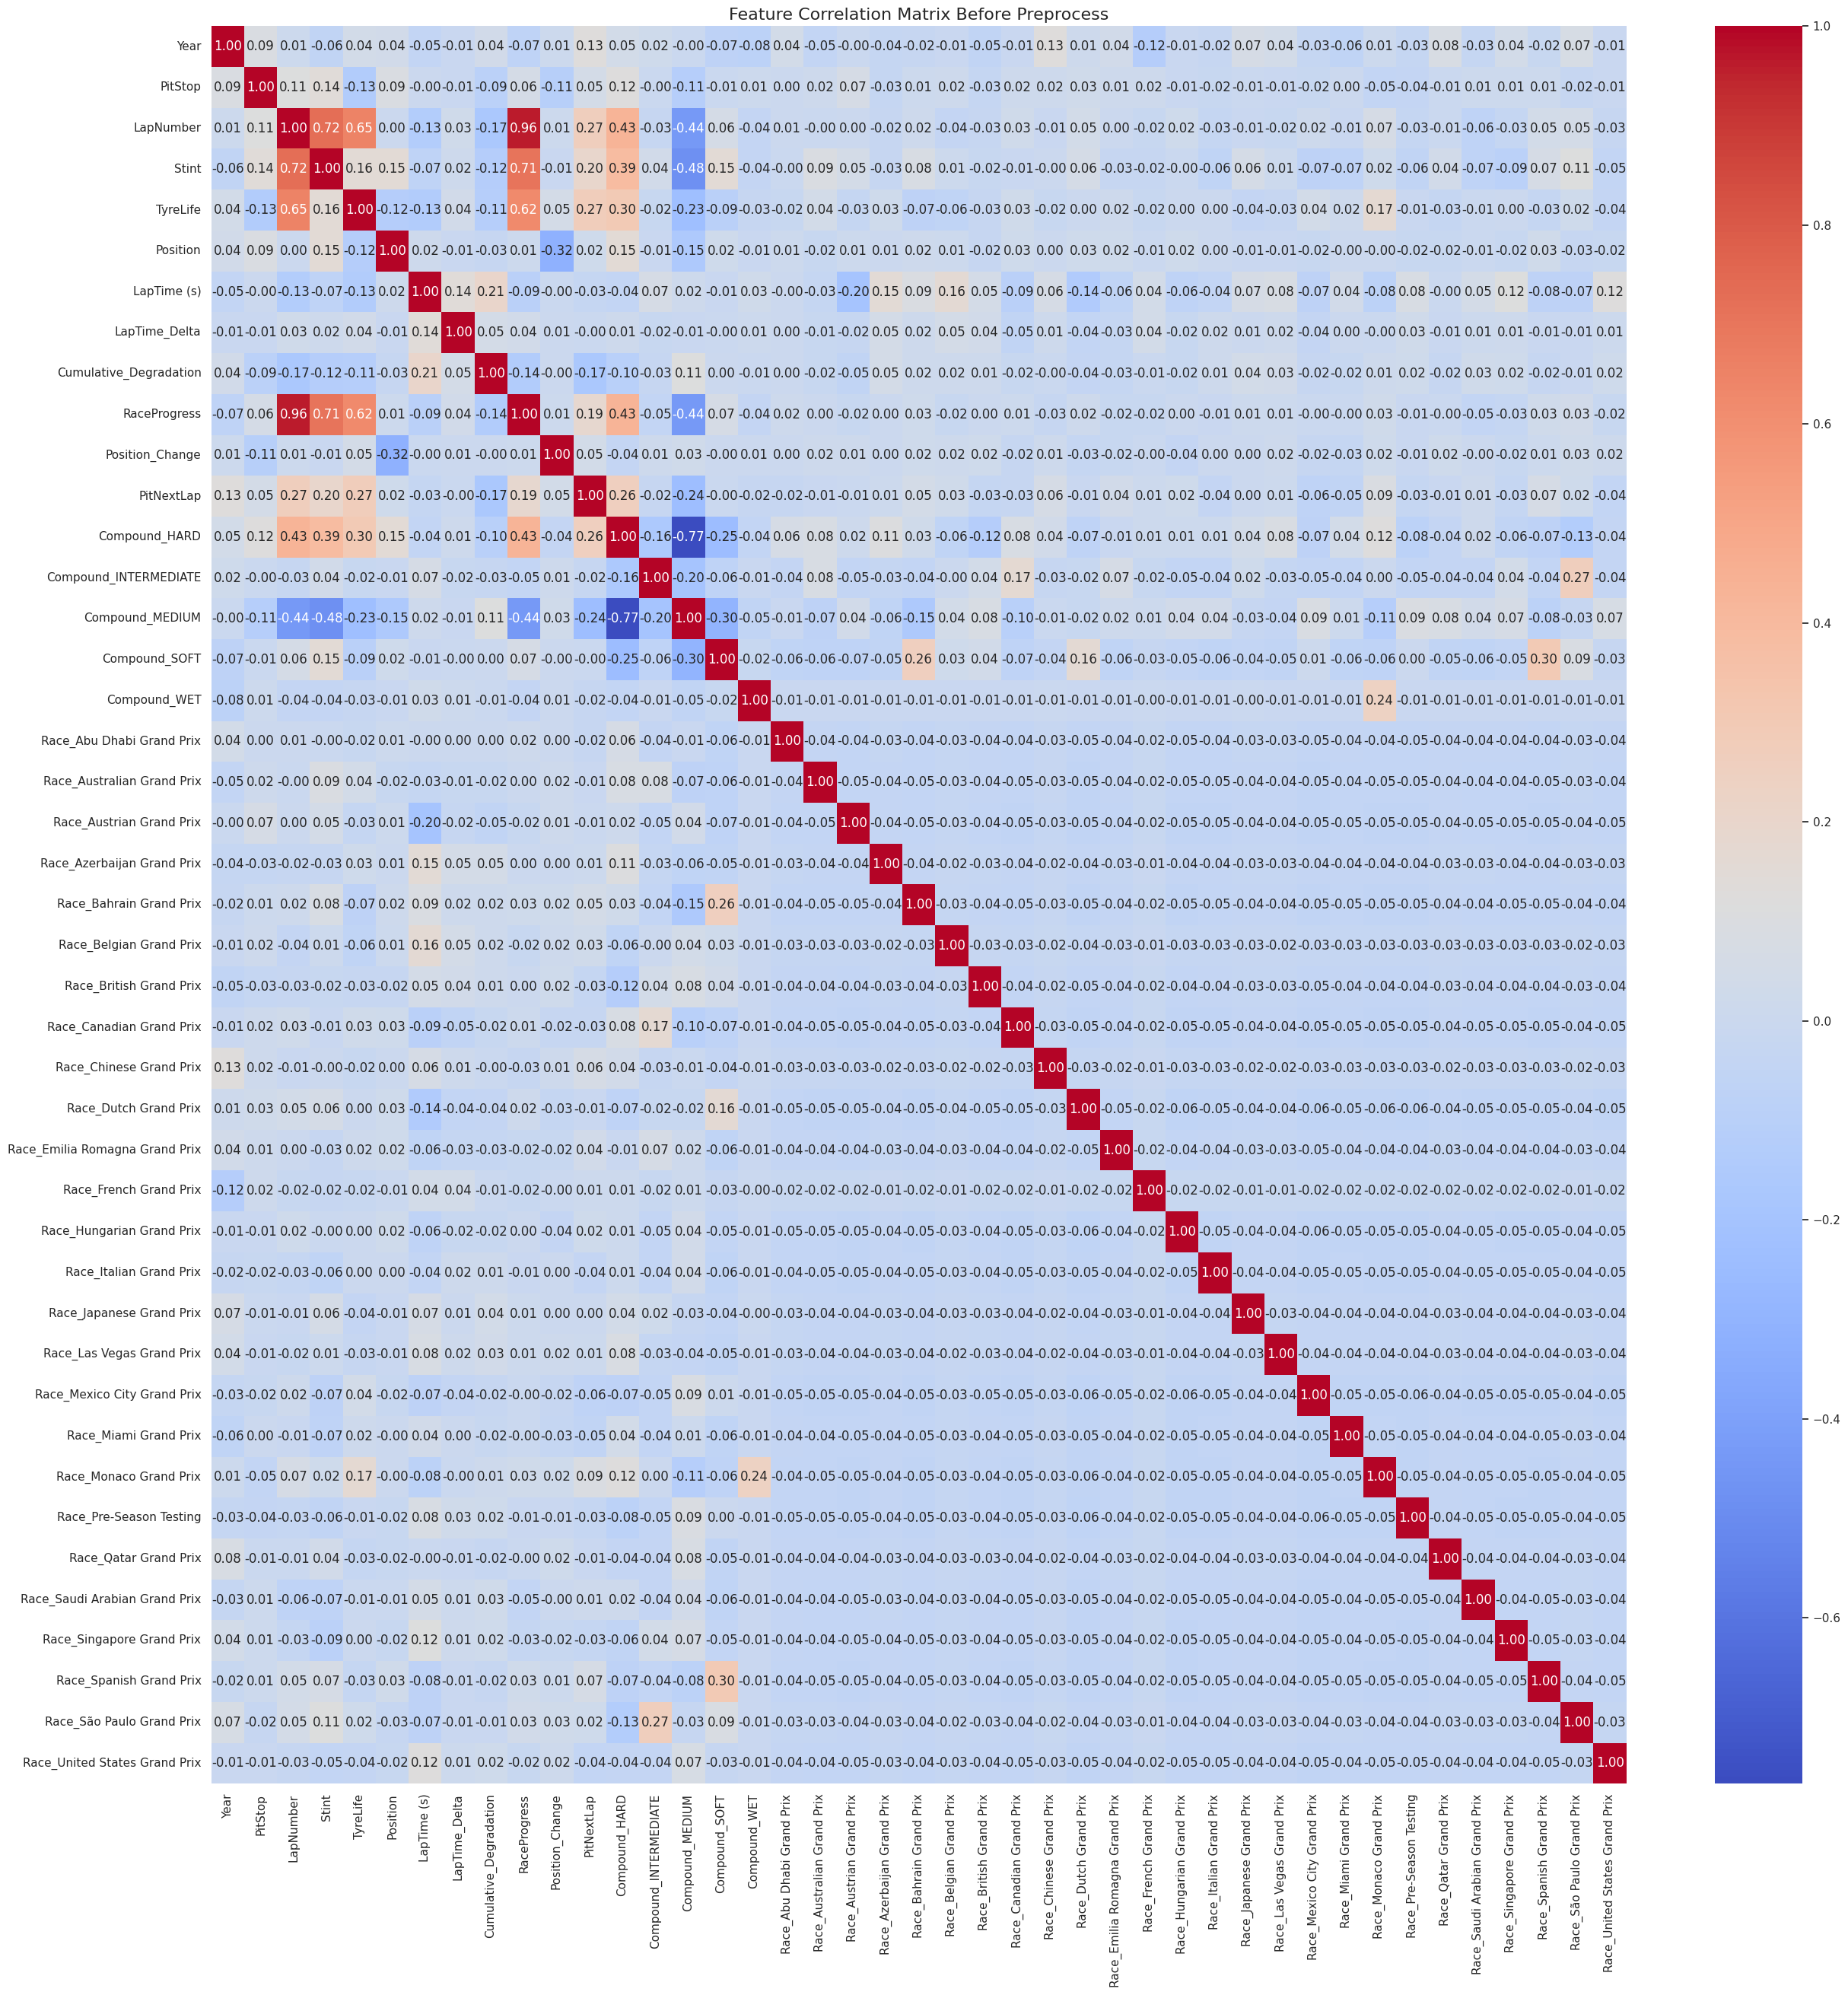

In [11]:
# Check the correlation map before preprocess
# Then compare it with the correlation map of after preprocess 
corr_matrix = one_hot_encoded_train_raw.corr()

# Setup the figure size (make it large enough to read)
plt.figure(figsize=(30, 30))

# Create the Heatmap
# annot=True: shows the numbers
# cmap='coolwarm': Blue for negative corr, Red for positive
# fmt=".2f": limits decimals to 2 places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Matrix Before Preprocess", fontsize=16)
plt.show()

# Preprocess Function (Claude Code)

In [12]:
"""
F1 PitNextLap - Complete Data Preprocessing Class
=================================================

Consolidates all 12 preprocessing recommendations from the EDA report
into a single sklearn-style class.

Usage:

    from f1_preprocessor import F1Preprocessor
    import pandas as pd

    df_train = pd.read_csv('train.csv')
    df_test  = pd.read_csv('test.csv')

    pre = F1Preprocessor(target='PitNextLap', drop_pre_season=True)
    X_train, y_train = pre.fit_transform(df_train, return_y=True)
    X_test           = pre.transform(df_test)

    # Then feed straight into a model
    import lightgbm as lgb
    model = lgb.LGBMClassifier(scale_pos_weight=pre.scale_pos_weight_)
    model.fit(X_train, y_train)

Design principles:
  * fit() must only see the train set. Every statistic (median lap time,
    target encoding, frequency tables) is computed during fit and stored,
    so transform() only does table lookups -> prevents data leakage.
  * Tree-model friendly: keeps original categorical columns and adds
    ordinal, frequency, and target-encoding features.
  * For linear models, apply a StandardScaler separately; this class
    does not scale features.
"""

from __future__ import annotations
import re
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold


class F1Preprocessor(BaseEstimator, TransformerMixin):
    # ---- Domain constants -------------------------------------------------
    COMPOUND_HARDNESS = {       # dry-tyre hardness ranking (wet tyres = 0)
        'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'INTERMEDIATE': 0, 'WET': 0,
    }
    EXPECTED_STINT = {          # empirical "expected usable laps" per compound
        'SOFT': 18, 'MEDIUM': 25, 'HARD': 35,
        'INTERMEDIATE': 20, 'WET': 15,
    }
    WET_COMPOUNDS = {'INTERMEDIATE', 'WET'}
    DRIVER_RARE_THRESHOLD = 50  # drivers with < 50 samples are grouped as OTHER
    LAPTIME_CLIP_QUANTILES = (0.005, 0.995)

    # ---- Interface --------------------------------------------------------
    def __init__(self,
                 target: str = 'PitNextLap',
                 drop_pre_season: bool = True,
                 use_target_encoding: bool = True,
                 te_smoothing: float = 20.0,
                 te_n_splits: int = 5,
                 add_lag_features: bool = True,
                 random_state: int = 42):
        self.target = target
        self.drop_pre_season = drop_pre_season
        self.use_target_encoding = use_target_encoding
        self.te_smoothing = te_smoothing
        self.te_n_splits = te_n_splits
        self.add_lag_features = add_lag_features
        self.random_state = random_state

    # =====================================================================
    # fit
    # =====================================================================
    def fit(self, df: pd.DataFrame, y=None):
        """Learn parameters from train. y is taken from df[target] automatically."""
        if self.drop_pre_season:
            df = df[df['Race'] != 'Pre-Season Testing'].copy()
        else:
            df = df.copy()

        y = df[self.target].astype(int).values
        self.global_pit_rate_ = float(np.mean(y))
        n_neg = int((y == 0).sum())
        n_pos = int((y == 1).sum())
        self.scale_pos_weight_ = n_neg / max(n_pos, 1)

        # 1. Median lap-time baseline per race (used for relative lap time)
        self.lap_baseline_ = (
            df.groupby(['Race', 'Year'])['LapTime (s)'].median().to_dict()
        )

        # 2. Lap-time clip bounds (also per Race x Year)
        lo_q, hi_q = self.LAPTIME_CLIP_QUANTILES
        self.lap_clip_ = (
            df.groupby(['Race', 'Year'])['LapTime (s)']
              .agg(lo=lambda s: s.quantile(lo_q),
                   hi=lambda s: s.quantile(hi_q))
              .to_dict('index')
        )

        # 3. Driver frequency table + whitelist of non-rare drivers
        drv_counts = df['Driver'].value_counts()
        self.driver_freq_ = drv_counts.to_dict()
        self.driver_keep_ = set(drv_counts[drv_counts >= self.DRIVER_RARE_THRESHOLD].index)

        # 4. Target encoding (smoothed; statistics computed on train only)
        if self.use_target_encoding:
            self.te_driver_ = self._fit_target_encoding(df, 'Driver', y)
            self.te_race_   = self._fit_target_encoding(df, 'Race', y)
        else:
            self.te_driver_ = self.te_race_ = {}

        # 5. Max stint length per race x compound (for derived features)
        self.compound_race_max_stint_ = (
            df.groupby(['Compound', 'Race'])['TyreLife'].max().to_dict()
        )

        self.feature_names_ = None  # filled in during transform
        return self

    def _fit_target_encoding(self, df, col, y):
        """Smoothed target encoding (shrinks rare categories toward the prior)."""
        prior = self.global_pit_rate_
        sm = self.te_smoothing
        agg = df.groupby(col)[self.target].agg(['mean', 'count'])
        smoothed = (agg['mean'] * agg['count'] + prior * sm) / (agg['count'] + sm)
        return smoothed.to_dict()

    # =====================================================================
    # transform
    # =====================================================================
    def transform(self, df: pd.DataFrame, return_y: bool = False):
        df = df.copy()
        # Pre-Season Testing: do not drop in transform (test set may contain it),
        # just add a flag column
        df['is_pre_season'] = (df['Race'] == 'Pre-Season Testing').astype(int)

        # ---------- Numeric cleaning ----------
        df = self._clip_extreme_laptime(df)
        df = self._add_relative_laptime(df)

        # ---------- Categorical encoding ----------
        df = self._encode_compound(df)
        df = self._encode_driver(df)
        if self.use_target_encoding:
            df['race_te']   = df['Race'].map(self.te_race_).fillna(self.global_pit_rate_)
            df['driver_te'] = df['Driver'].map(self.te_driver_).fillna(self.global_pit_rate_)

        # ---------- Domain-derived features ----------
        df = self._add_tyre_features(df)
        df = self._add_position_features(df)
        df = self._add_progress_features(df)

        # ---------- Time-series features ----------
        if self.add_lag_features:
            df = self._add_lag_features(df)

        # ---------- Split into X / y ----------
        drop_cols = ['id', 'Driver', 'Compound', 'Race']
        if return_y:
            y = df[self.target].astype(int).values
            X = df.drop(columns=drop_cols + [self.target], errors='ignore')
            self.feature_names_ = list(X.columns)
            return X, y
        X = df.drop(columns=drop_cols + [self.target], errors='ignore')
        self.feature_names_ = list(X.columns)
        return X

    def fit_transform(self, df, y=None, return_y: bool = True):
        self.fit(df)
        # fit() already drops pre-season; transform must use the same rows
        if self.drop_pre_season:
            df = df[df['Race'] != 'Pre-Season Testing'].copy()
        return self.transform(df, return_y=return_y)

    # =====================================================================
    # Detailed steps
    # =====================================================================
    def _clip_extreme_laptime(self, df):
        """Clip each race's lap times to the 0.5%~99.5% range and flag anomalies."""
        global_lo = np.quantile(list(self.lap_baseline_.values()), 0.01)
        global_hi = np.quantile(list(self.lap_baseline_.values()), 0.99) * 2

        def _clip(row):
            key = (row['Race'], row['Year'])
            bounds = self.lap_clip_.get(key)
            if bounds is None:
                return np.clip(row['LapTime (s)'], global_lo, global_hi)
            return np.clip(row['LapTime (s)'], bounds['lo'], bounds['hi'])

        # For speed, look up the bounds via map then compute in one pass
        lo = df.set_index(['Race', 'Year']).index.map(
            lambda k: self.lap_clip_.get(k, {}).get('lo', global_lo))
        hi = df.set_index(['Race', 'Year']).index.map(
            lambda k: self.lap_clip_.get(k, {}).get('hi', global_hi))
        original = df['LapTime (s)'].values
        clipped = np.clip(original, lo.astype(float), hi.astype(float))
        df['is_anomaly_lap'] = (original != clipped).astype(int)
        df['LapTime_clipped'] = clipped
        df['LapTime_log'] = np.log1p(np.clip(clipped, 1, None))
        return df

    def _add_relative_laptime(self, df):
        """Lap time relative to that race's median lap time."""
        baseline = df.set_index(['Race', 'Year']).index.map(
            lambda k: self.lap_baseline_.get(k, np.nan))
        baseline = pd.Series(baseline, index=df.index, dtype=float)
        # If the test set has a race unseen in train, fall back to the global median
        baseline = baseline.fillna(np.median(list(self.lap_baseline_.values())))
        df['lap_baseline']  = baseline.values
        df['LapTime_diff']  = df['LapTime_clipped'] - baseline
        df['LapTime_ratio'] = df['LapTime_clipped'] / baseline
        return df

    def _encode_compound(self, df):
        df['compound_hardness'] = df['Compound'].map(self.COMPOUND_HARDNESS).fillna(0).astype(int)
        df['is_wet_tyre'] = df['Compound'].isin(self.WET_COMPOUNDS).astype(int)
        # Keep a one-hot copy as well, useful for linear models
        for c in ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']:
            df[f'compound_{c}'] = (df['Compound'] == c).astype(int)
        return df

    def _encode_driver(self, df):
        df['driver_freq'] = df['Driver'].map(self.driver_freq_).fillna(0).astype(int)
        df['driver_is_real'] = df['Driver'].astype(str).str.match(r'^[A-Z]{3}$').astype(int)
        df['driver_clean'] = df['Driver'].where(df['Driver'].isin(self.driver_keep_), 'OTHER')
        # driver_clean can be fed to LightGBM as a categorical directly;
        # here we label-encode it
        df['driver_clean_id'] = df['driver_clean'].astype('category').cat.codes
        return df.drop(columns=['driver_clean'])

    def _add_tyre_features(self, df):
        # Median life per compound
        med_life = {'SOFT': 10, 'MEDIUM': 11, 'HARD': 17, 'INTERMEDIATE': 12, 'WET': 9}
        df['tyre_life_ratio'] = df['TyreLife'] / df['Compound'].map(med_life).fillna(15)
        df['tyre_life_vs_expected'] = df['TyreLife'] / df['Compound'].map(self.EXPECTED_STINT).fillna(25)
        # Historical longest stint for the same race-compound pair
        key = list(zip(df['Compound'], df['Race']))
        df['compound_race_max_stint'] = [self.compound_race_max_stint_.get(k, np.nan) for k in key]
        df['compound_race_max_stint'] = df['compound_race_max_stint'].fillna(df['TyreLife'].median())
        df['tyre_life_vs_max'] = df['TyreLife'] / df['compound_race_max_stint'].clip(lower=1)
        return df

    def _add_position_features(self, df):
        df['in_points']        = (df['Position'] <= 10).astype(int)
        df['top3']             = (df['Position'] <= 3).astype(int)
        df['gained_pos']       = (df['Position_Change'] > 0).astype(int)
        df['lost_pos']         = (df['Position_Change'] < 0).astype(int)
        df['pos_gap_to_leader']= df['Position'] - 1
        return df

    def _add_progress_features(self, df):
        df['lap_remaining_pct'] = (1 - df['RaceProgress']).clip(lower=0)
        # Mid-race window (the range where pit stops happen most often)
        df['is_mid_race'] = ((df['RaceProgress'] >= 0.30) &
                             (df['RaceProgress'] <= 0.70)).astype(int)
        df['stint_lap_norm'] = df['TyreLife'] / df['Stint'].clip(lower=1)
        return df

    def _add_lag_features(self, df):
        """Build lag / rolling features grouped by (Race, Year, Driver, Stint).
        Note: df must contain LapNumber, and row order must be preserved."""
        df = df.sort_values(['Race', 'Year', 'Driver', 'Stint', 'LapNumber'])
        g = df.groupby(['Race', 'Year', 'Driver', 'Stint'], sort=False)

        for k in (1, 2, 3):
            df[f'lap_lag{k}']      = g['LapTime_clipped'].shift(k)
            df[f'lap_diff_lag{k}'] = df['LapTime_clipped'] - df[f'lap_lag{k}']

        df['lap_roll3_mean'] = g['LapTime_clipped'].transform(
            lambda s: s.rolling(3, min_periods=1).mean())
        df['lap_roll3_std']  = g['LapTime_clipped'].transform(
            lambda s: s.rolling(3, min_periods=2).std())
        df['lap_roll5_mean'] = g['LapTime_clipped'].transform(
            lambda s: s.rolling(5, min_periods=1).mean())

        # NaN (first few laps of each stint) -> 0; also add a mask column
        # so the model knows the value was missing
        for c in ['lap_lag1','lap_lag2','lap_lag3',
                  'lap_diff_lag1','lap_diff_lag2','lap_diff_lag3',
                  'lap_roll3_std']:
            df[f'{c}_isna'] = df[c].isna().astype(int)
            df[c] = df[c].fillna(0)
        df['lap_roll3_mean'] = df['lap_roll3_mean'].fillna(df['LapTime_clipped'])
        df['lap_roll5_mean'] = df['lap_roll5_mean'].fillna(df['LapTime_clipped'])

        return df.sort_index()

    # =====================================================================
    # CV split helper: avoid time-series leakage
    # =====================================================================
    @staticmethod
    def make_groups(df: pd.DataFrame) -> pd.Series:
        """Return a group id made of Race+Year, for use with GroupKFold."""
        return (df['Race'].astype(str) + '_' + df['Year'].astype(str))


# ===========================================================================
# Full usage example
# ===========================================================================
if __name__ == '__main__':
    import pandas as pd
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import roc_auc_score
    import lightgbm as lgb

    df = pd.read_csv(CFG.train_csv)
    pre = F1Preprocessor(target='PitNextLap',
                         drop_pre_season=True,
                         use_target_encoding=True,
                         add_lag_features=True)

    X, y = pre.fit_transform(df, return_y=True)
    print('shape:', X.shape, 'pos rate:', y.mean(), 'spw:', pre.scale_pos_weight_)

    groups = pre.make_groups(df[df['Race'] != 'Pre-Season Testing'])
    gkf = GroupKFold(n_splits=5)
    scores = []
    for fold, (tr, va) in enumerate(gkf.split(X, y, groups=groups)):
        model = lgb.LGBMClassifier(
            n_estimators=600, learning_rate=0.05,
            num_leaves=63, min_child_samples=200,
            scale_pos_weight=pre.scale_pos_weight_,
            random_state=42,
        )
        model.fit(X.iloc[tr], y[tr],
                  eval_set=[(X.iloc[va], y[va])],
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        p = model.predict_proba(X.iloc[va])[:, 1]
        auc = roc_auc_score(y[va], p)
        scores.append(auc)
        print(f'fold {fold}: AUC = {auc:.4f}')
    print(f'mean AUC = {np.mean(scores):.4f}')

shape: (416648, 58) pos rate: 0.20181304122424684 spw: 3.95508116786585
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 68309, number of negative: 264978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6669
[LightGBM] [Info] Number of data points in the train set: 333287, number of used features: 57
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.204955 -> initscore=-1.355605
[LightGBM] [Info] Start training from score -1.355605
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[20]	valid_0's binary_logloss: 0.369903
fold 0: AUC = 0.8899
[LightGBM] [Warning] Found whitespace in feature_na